# Data Science Project 3 - Customer Segmentation

**Step 1: Import Libraries**


In [26]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


**Step 2: Load and Explore Data**

In [27]:
# IMPORTANT FIX: Use sep='\t' because the data is tab-separated
df = pd.read_csv('Data Science Project 3.csv', sep='\t')

print("=" * 80)
print("📊 DATA OVERVIEW")
print("=" * 80)
print(f"Total customers: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

# Look at first few rows
print("\n📄 First 5 Rows of Data:")
print(df.head())

# Check column names
print("\n📋 All Column Names:")
print(df.columns.tolist())

# Check data types
print("\n📊 Data Types:")
print(df.dtypes)

# Check missing values
print("\n🔍 Missing Values in Each Column:")
print(df.isnull().sum())

# Find columns with missing data
print("\n📊 Columns with Missing Data:")
for col in df.columns:
    missing = df[col].isnull().sum()
    if missing > 0:
        print(f"   {col}: {missing} Missing Values")

# Remove rows where Income is missing (now it will work because columns are proper)
df = df.dropna(subset=['Income'])

print(f"\n✅ After Removing Missing Income: {df.shape[0]} Customers Left")

# Display cleaned data
print("\n📄 First 5 Rows After Cleaning:")
print(df.head())

print(f"\n✅ Final Data Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")

📊 DATA OVERVIEW
Total customers: 2240
Total columns: 29

📄 First 5 Rows of Data:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  04-09-2012       58       635         88              546              172   
1  08-03-2014       38        11          1                6                2   
2  21-08-2013       26       426         49              127              111   
3  10-02-2014       26        11          4               20               10   
4  19-01-2014       94       173         43  

**Step 3: Select Features for Clustering**

In [28]:
# These are the exact column names from your CSV
features = [
    'Income',
    'Kidhome',
    'Teenhome',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]

# Create feature matrix
X = df[features].copy()

print("=" * 80)
print("🎯 SELECTED FEATURES FOR CLUSTERING")
print("=" * 80)
print(f"Total Features: {len(features)}")
print("\nFeature Names:")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

print(f"\nShape of Feature Matrix: {X.shape}")
print("\n📊 First 5 rows:")
print(X.head())

print("\n📊 Feature Statistics:")
print(X.describe())

🎯 SELECTED FEATURES FOR CLUSTERING
Total Features: 15

Feature Names:
  1. Income
  2. Kidhome
  3. Teenhome
  4. Recency
  5. MntWines
  6. MntFruits
  7. MntMeatProducts
  8. MntFishProducts
  9. MntSweetProducts
  10. MntGoldProds
  11. NumDealsPurchases
  12. NumWebPurchases
  13. NumCatalogPurchases
  14. NumStorePurchases
  15. NumWebVisitsMonth

Shape of Feature Matrix: (2216, 15)

📊 First 5 rows:
    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  \
0              172                88  

**Step 4: Scale the Data**

In [29]:
# StandardScaler - makes all features equally important
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for easy viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("=" * 80)
print("📏 DATA SCALING COMPLETE")
print("=" * 80)
print("✅ Features Standardized (mean=0, std=1)")

print("\n📊 First 5 Rows of Scaled Data:")
print(X_scaled_df.head())

print("\n📊 Scaled Data Statistics:")
print(X_scaled_df.describe())

📏 DATA SCALING COMPLETE
✅ Features Standardized (mean=0, std=1)

📊 First 5 Rows of Scaled Data:
     Income   Kidhome  Teenhome   Recency  MntWines  MntFruits  \
0  0.234063 -0.823039 -0.928972  0.310532  0.978226   1.549429   
1 -0.234559  1.039938  0.909066 -0.380509 -0.872024  -0.637328   
2  0.769478 -0.823039 -0.928972 -0.795134  0.358511   0.569159   
3 -1.017239  1.039938 -0.928972 -0.795134 -0.872024  -0.561922   
4  0.240221  1.039938 -0.928972  1.554407 -0.391671   0.418348   

   MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
0         1.690227         2.454568          1.484827      0.850031   
1        -0.717986        -0.651038         -0.633880     -0.732867   
2        -0.178368         1.340203         -0.146821     -0.037937   
3        -0.655551        -0.504892         -0.585174     -0.752171   
4        -0.218505         0.152766         -0.000703     -0.559135   

   NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \

**Step 5: Principal Component Analysis (PCA)**

📉 PRINCIPAL COMPONENT ANALYSIS (PCA)
Explained Variance by each Component:
  PC1: 40.44%
  PC2: 12.28%
  PC3: 6.79%

Total Variance Explained by 3 Components: 59.50%
✅ Reduced 15 Features to 3 Dimensions


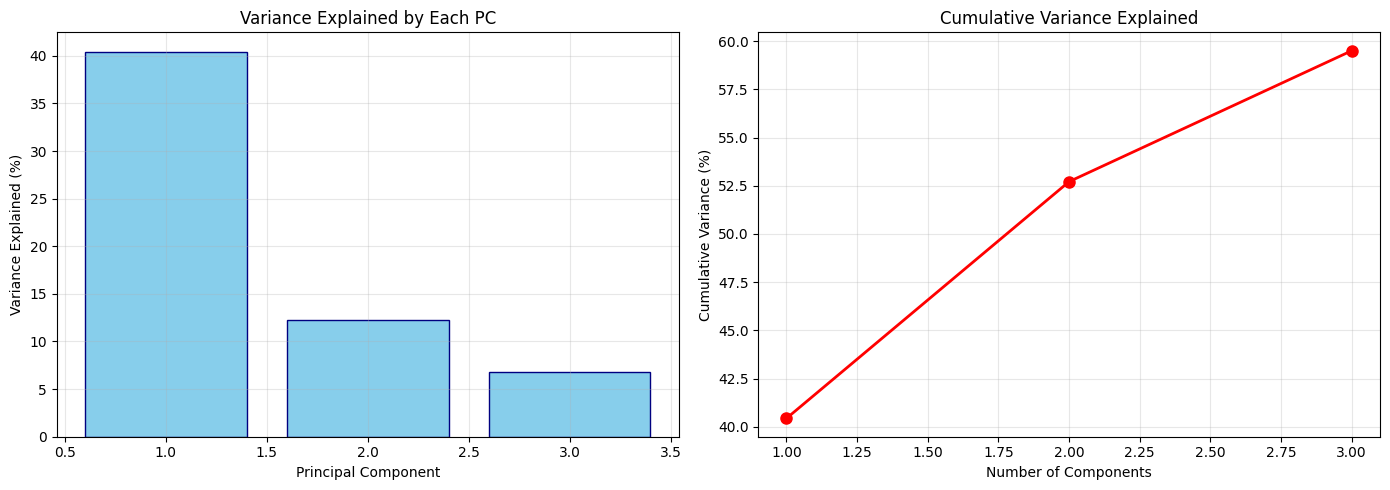

In [30]:
# Apply PCA to reduce dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Also get 2D for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Calculate explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("=" * 80)
print("📉 PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 80)

print("Explained Variance by each Component:")
for i, var in enumerate(explained_var, 1):
    print(f"  PC{i}: {var*100:.2f}%")

print(f"\nTotal Variance Explained by 3 Components: {sum(explained_var)*100:.2f}%")
print(f"✅ Reduced {len(features)} Features to 3 Dimensions")

# Visualize PCA variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1.bar(range(1, 4), explained_var * 100, color='skyblue', edgecolor='navy')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('Variance Explained by Each PC')
ax1.grid(True, alpha=0.3)

# Cumulative plot
ax2.plot(range(1, 4), cumulative_var * 100, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Variance Explained')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Step 6: Elbow Method - Find Optimal K**

🎯 ELBOW METHOD - Finding Optimal K
K =  1: WCSS = 19,779
K =  2: WCSS = 9,133
K =  3: WCSS = 6,057
K =  4: WCSS = 5,224
K =  5: WCSS = 4,561
K =  6: WCSS = 4,005
K =  7: WCSS = 3,544
K =  8: WCSS = 3,264
K =  9: WCSS = 3,052
K = 10: WCSS = 2,859
K = 11: WCSS = 2,660
K = 12: WCSS = 2,520


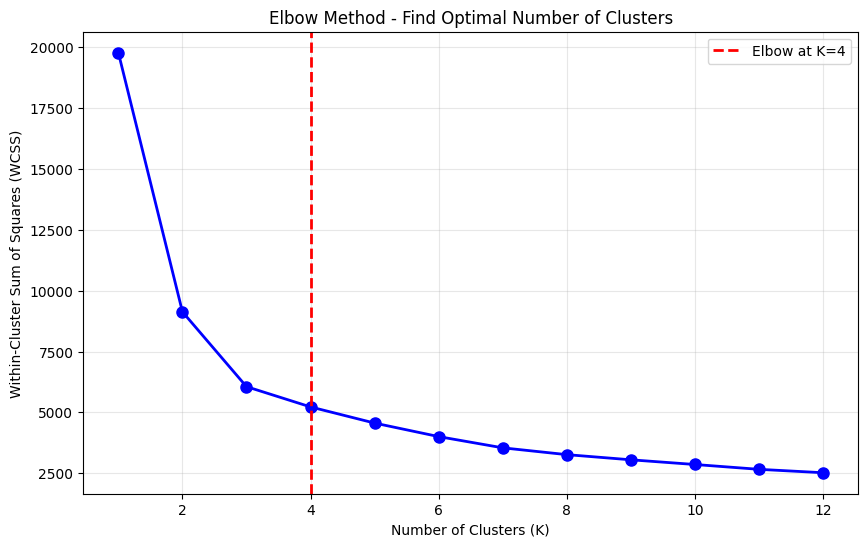


✅ The 'Elbow' Appears at K = 4
✅ 4 Clusters is optimal based on WCSS


In [31]:
# Elbow Method - As required in PDF

wcss = []  # Within-Cluster Sum of Squares

print("=" * 80)
print("🎯 ELBOW METHOD - Finding Optimal K")
print("=" * 80)

# Test K from 1 to 12
for k in range(1, 13):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    print(f"K = {k:2d}: WCSS = {kmeans.inertia_:,.0f}")

# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 13), wcss, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='r', linestyle='--', label='Elbow at K=4', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method - Find Optimal Number of Clusters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ The 'Elbow' Appears at K = 4")
print("✅ 4 Clusters is optimal based on WCSS")

**Step 7: Silhouette Score - Confirm Optimal K**

🎯 SILHOUETTE SCORE - Confirming Optimal K
K =  2: Silhouette Score = 0.4794
K =  3: Silhouette Score = 0.4442
K =  4: Silhouette Score = 0.4049
K =  5: Silhouette Score = 0.3649
K =  6: Silhouette Score = 0.3385
K =  7: Silhouette Score = 0.3145
K =  8: Silhouette Score = 0.3075
K =  9: Silhouette Score = 0.3160
K = 10: Silhouette Score = 0.3113
K = 11: Silhouette Score = 0.3119
K = 12: Silhouette Score = 0.3028


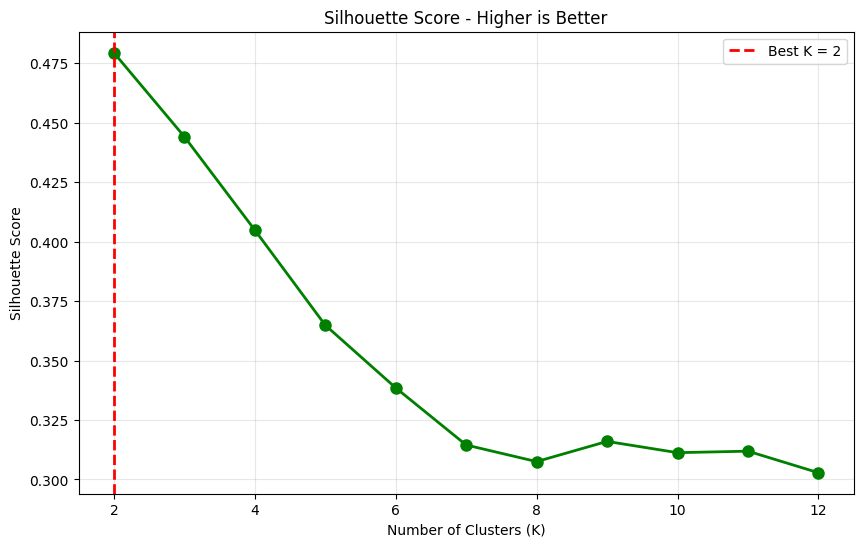


✅ Best K = 2 (Silhouette Score: 0.4794)
✅ Final Optimal K = 2


In [32]:
# Silhouette Score - As required in PDF

silhouette_scores = []

print("=" * 80)
print("🎯 SILHOUETTE SCORE - Confirming Optimal K")
print("=" * 80)

for k in range(2, 13):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"K = {k:2d}: Silhouette Score = {score:.4f}")

# Find best K
best_k = np.argmax(silhouette_scores) + 2

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 13), silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K = {best_k}', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Higher is Better')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✅ Best K = {best_k} (Silhouette Score: {max(silhouette_scores):.4f})")
print(f"✅ Final Optimal K = {best_k}")

**Step 8: Apply K-Means Clustering**

🎯 K-MEANS CLUSTERING COMPLETE
Number of Clusters: 2

📊 Cluster Distribution:
  Cluster 0: 1317 Customers ( 59.4%)
  Cluster 1:  899 Customers ( 40.6%)


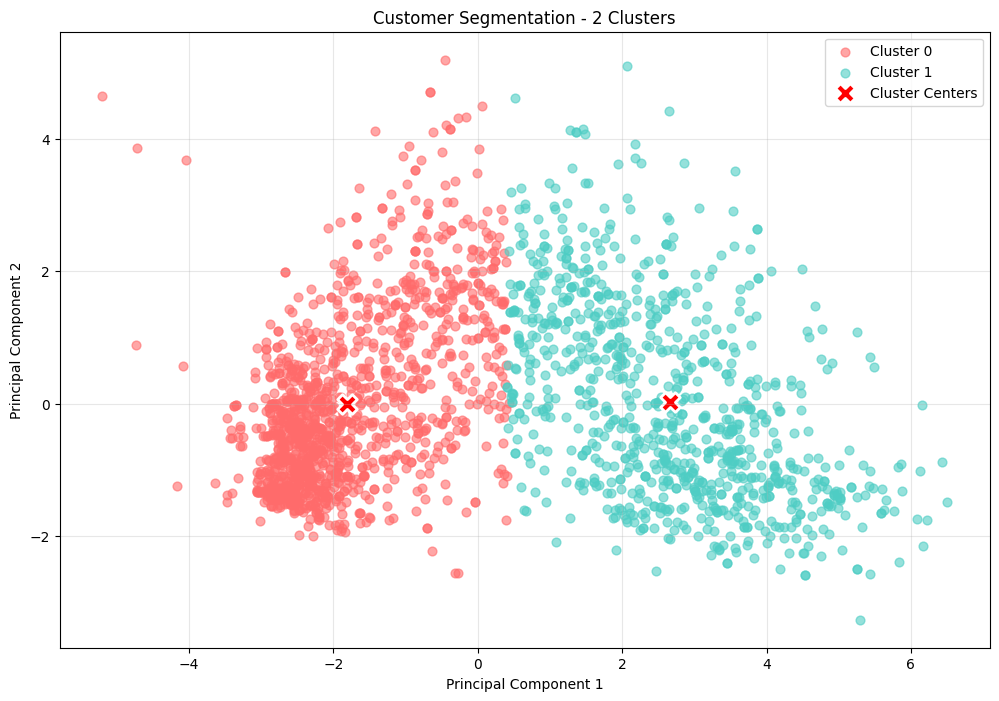


✅ Clustering and Visualization Complete!


In [39]:
# Set optimal K
K = best_k

# Apply K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

print("=" * 80)
print("🎯 K-MEANS CLUSTERING COMPLETE")
print("=" * 80)
print(f"Number of Clusters: {K}")

# Cluster distribution
cluster_counts = df['Cluster'].value_counts().sort_index()
print("\n📊 Cluster Distribution:")
for cluster in range(K):
    count = cluster_counts.get(cluster, 0)
    percentage = (count / len(df)) * 100
    print(f"  Cluster {cluster}: {count:4d} Customers ({percentage:5.1f}%)")

# Visualize clusters in 2D
plt.figure(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFA07A', '#9370DB'][:K]
for cluster in range(K):
    mask = df['Cluster'] == cluster
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=colors[cluster], label=f'Cluster {cluster}', alpha=0.6, s=40)

# FIX: Convert 3D centers to 2D
centers_3d = kmeans.cluster_centers_
centers_2d = centers_3d[:, :2]  # Corrected: Take the first two components

plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
           c='red', marker='X', s=200, edgecolors='white', linewidth=2,
           label='Cluster Centers')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Customer Segmentation - {K} Clusters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ Clustering and Visualization Complete!")

**Step 9: Analyze Cluster Characteristics**

📊 CLUSTER PROFILES (Average Values)

CLUSTER 0
💰 Income:              $    38,800
👶 Kids at Home:               0.7
🧑 Teens at Home:              0.6
📅 Days Since Purchase:       48.8
🍷 Wine Spending:       $       106
🍎 Fruit Spending:      $         6
🥩 Meat Spending:       $        37
🐟 Fish Spending:       $         9
🍬 Sweet Spending:      $         6
💎 Gold Spending:       $        22
🛒 Deal Purchases:             2.6
💻 Web Purchases:              2.9
📚 Catalog Purchases:          0.9
🏪 Store Purchases:            3.9
🌐 Website Visits:             6.4

CLUSTER 1
💰 Income:              $    71,947
👶 Kids at Home:               0.1
🧑 Teens at Home:              0.4
📅 Days Since Purchase:       49.4
🍷 Wine Spending:       $       596
🍎 Fruit Spending:      $        56
🥩 Meat Spending:       $       358
🐟 Fish Spending:       $        79
🍬 Sweet Spending:      $        58
💎 Gold Spending:       $        76
🛒 Deal Purchases:             2.0
💻 Web Purchases:              5.8
📚 Catalog 

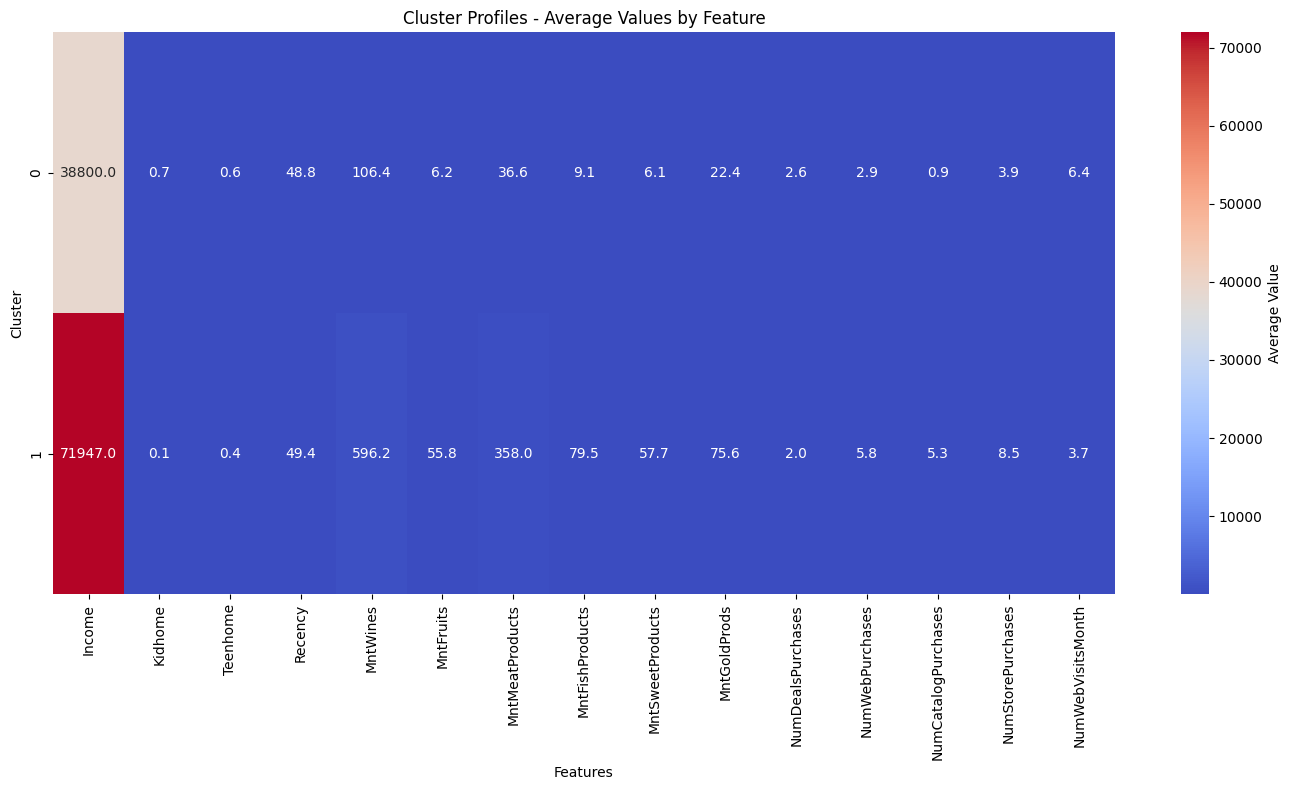

In [40]:
# Calculate average values for each cluster
cluster_avg = df.groupby('Cluster')[features].mean()

print("=" * 80)
print("📊 CLUSTER PROFILES (Average Values)")
print("=" * 80)

# Display with formatting
for cluster in range(K):
    row = cluster_avg.loc[cluster]
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*50}")
    print(f"💰 Income:              ${row['Income']:10,.0f}")
    print(f"👶 Kids at Home:        {row['Kidhome']:10.1f}")
    print(f"🧑 Teens at Home:       {row['Teenhome']:10.1f}")
    print(f"📅 Days Since Purchase: {row['Recency']:10.1f}")
    print(f"🍷 Wine Spending:       ${row['MntWines']:10,.0f}")
    print(f"🍎 Fruit Spending:      ${row['MntFruits']:10,.0f}")
    print(f"🥩 Meat Spending:       ${row['MntMeatProducts']:10,.0f}")
    print(f"🐟 Fish Spending:       ${row['MntFishProducts']:10,.0f}")
    print(f"🍬 Sweet Spending:      ${row['MntSweetProducts']:10,.0f}")
    print(f"💎 Gold Spending:       ${row['MntGoldProds']:10,.0f}")
    print(f"🛒 Deal Purchases:      {row['NumDealsPurchases']:10.1f}")
    print(f"💻 Web Purchases:       {row['NumWebPurchases']:10.1f}")
    print(f"📚 Catalog Purchases:   {row['NumCatalogPurchases']:10.1f}")
    print(f"🏪 Store Purchases:     {row['NumStorePurchases']:10.1f}")
    print(f"🌐 Website Visits:      {row['NumWebVisitsMonth']:10.1f}")

# Heatmap visualization
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_avg, annot=True, fmt='.1f', cmap='coolwarm',
            cbar_kws={'label': 'Average Value'})
plt.title('Cluster Profiles - Average Values by Feature')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

**Step 10: Create Customer Personas**

In [41]:
print("\n" + "=" * 80)
print("👤 CUSTOMER PERSONAS (Business Translation)")
print("=" * 80)

personas = []

for cluster in range(K):
    row = cluster_avg.loc[cluster]

    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*50}")

    # Determine persona based on key characteristics
    if row['Income'] > 70000 and row['MntWines'] > 500:
        persona = "💰 HIGH-VALUE PREMIUM SHOPPER"
        desc = "Affluent customers who spend heavily on premium products"
        strategy = "VIP program, exclusive product access, personalized service"
        emoji = "👑"

    elif row['NumWebPurchases'] > 5 and row['Recency'] < 30:
        persona = "💻 DIGITAL-FIRST SHOPPER"
        desc = "Tech-savvy customers who prefer online shopping"
        strategy = "Mobile app optimization, email marketing, free shipping"
        emoji = "📱"

    elif row['MntMeatProducts'] > 200 and row['Kidhome'] > 0.5:
        persona = "👨‍👩‍👧‍👦 FAMILY SHOPPER"
        desc = "Family-oriented customers buying in bulk"
        strategy = "Family meal deals, bulk discounts, recipe suggestions"
        emoji = "🏠"

    elif row['NumDealsPurchases'] > 3 and row['Income'] < 50000:
        persona = "🎯 DEAL SEEKER"
        desc = "Price-conscious customers looking for discounts"
        strategy = "Discount coupons, flash sales, price match"
        emoji = "🏷️"

    else:
        persona = "🛍️ REGULAR CUSTOMER"
        desc = "Balanced shopping behavior across categories"
        strategy = "General promotions, loyalty program"
        emoji = "⭐"

    personas.append({
        'cluster': cluster,
        'name': persona,
        'description': desc,
        'strategy': strategy,
        'emoji': emoji
    })

    print(f"👤 Persona: {persona}")
    print(f"📝 Description: {desc}")
    print(f"🎯 Strategy: {strategy}")

    print(f"\n📊 Key Stats:")
    print(f"   • Income: ${row['Income']:,.0f}")
    print(f"   • Web Purchases: {row['NumWebPurchases']:.1f}")
    print(f"   • Wine Spend: ${row['MntWines']:.0f}")
    print(f"   • Days Since Purchase: {row['Recency']:.1f}")
    print(f"   • Kids at Home: {row['Kidhome']:.1f}")


👤 CUSTOMER PERSONAS (Business Translation)

CLUSTER 0
👤 Persona: 🛍️ REGULAR CUSTOMER
📝 Description: Balanced shopping behavior across categories
🎯 Strategy: General promotions, loyalty program

📊 Key Stats:
   • Income: $38,800
   • Web Purchases: 2.9
   • Wine Spend: $106
   • Days Since Purchase: 48.8
   • Kids at Home: 0.7

CLUSTER 1
👤 Persona: 💰 HIGH-VALUE PREMIUM SHOPPER
📝 Description: Affluent customers who spend heavily on premium products
🎯 Strategy: VIP program, exclusive product access, personalized service

📊 Key Stats:
   • Income: $71,947
   • Web Purchases: 5.8
   • Wine Spend: $596
   • Days Since Purchase: 49.4
   • Kids at Home: 0.1


**Step 11: Final Summary and Save Results**

In [45]:
print("\n" + "=" * 80)
print("📈 PROJECT FINAL SUMMARY")
print("=" * 80)

print(f"""
✅ PROJECT COMPLETED SUCCESSFULLY
──────────────────────────────────────────────────────────────────
📊 DATA SUMMARY
   • Total Customers Analyzed: {len(df):,}
   • Features Used for Clustering: {len(features)}
   • PCA Components: 3 (preserved {sum(explained_var)*100:.1f}% variance)

🎯 CLUSTERING RESULTS
   • Optimal Clusters: {K}
   • Best Silhouette Score: {max(silhouette_scores):.4f}
   • Elbow Method Confirmed: K = {K}

👤 CUSTOMER PERSONAS DISCOVERED
""")

for p in personas:
    count = cluster_counts.get(p['cluster'], 0)
    percent = (count / len(df)) * 100
    print(f"   {p['emoji']} Cluster {p['cluster']}: {p['name']}")
    print(f"      • {count} customers ({percent:.1f}%)")
    print(f"      • {p['description']}")

print(f"""
💡 BUSINESS VALUE
   • Targeted marketing campaigns for each segment
   • Personalized product recommendations
   • Optimized marketing budget allocation
   • Improved customer retention strategies

📁 FILES SAVED
   • 'customer_segments_final.csv' - Full data with cluster labels
   • 'cluster_profiles_final.csv' - Average values by cluster
""")

# Save results
df.to_csv('Cleaned Data Science Project 3.csv', index=False)
cluster_avg.to_csv('cluster_profiles_final.csv')

print("✅ Files Saved Successfully!")


📈 PROJECT FINAL SUMMARY

✅ PROJECT COMPLETED SUCCESSFULLY
──────────────────────────────────────────────────────────────────
📊 DATA SUMMARY
   • Total Customers Analyzed: 2,216
   • Features Used for Clustering: 15
   • PCA Components: 3 (preserved 59.5% variance)

🎯 CLUSTERING RESULTS
   • Optimal Clusters: 2
   • Best Silhouette Score: 0.4794
   • Elbow Method Confirmed: K = 2

👤 CUSTOMER PERSONAS DISCOVERED

   ⭐ Cluster 0: 🛍️ REGULAR CUSTOMER
      • 1317 customers (59.4%)
      • Balanced shopping behavior across categories
   👑 Cluster 1: 💰 HIGH-VALUE PREMIUM SHOPPER
      • 899 customers (40.6%)
      • Affluent customers who spend heavily on premium products

💡 BUSINESS VALUE
   • Targeted marketing campaigns for each segment
   • Personalized product recommendations
   • Optimized marketing budget allocation
   • Improved customer retention strategies

📁 FILES SAVED
   • 'customer_segments_final.csv' - Full data with cluster labels
   • 'cluster_profiles_final.csv' - Average 